In [ ]:
import mne
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mne.channels import make_dig_montage
import neurokit2 as nk
import scipy

In [ ]:
data_path = ".\sub1\sub-001_ses-01_task-GXtESCTT_eeg.set"
raw = mne.io.read_raw_eeglab(data_path, preload=True)

Reading d:\Developer\EEG_dataset\sub1\sub-001_ses-01_task-GXtESCTT_eeg.fdt


C:\Users\Jose\AppData\Local\Temp\ipykernel_17668\2235775890.py:2: RuntimeWarning: Estimated head radius (0.0 cm) is below the 3rd percentile for infant head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(data_path, preload=True)


Reading 0 ... 8455575  =      0.000 ...  4227.788 secs...


In [ ]:
raw = raw.set_eeg_reference("average")
raw = raw.filter(l_freq=4, h_freq=999)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 30 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 30.00
- Lower transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 26.25 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 881 samples (0.441 s)



In [ ]:
non_eeg_channels = {
    'BIP1': 'ecg',
    'BIP2': 'eog', 
    'RESP1': 'resp'
}

raw.set_channel_types(non_eeg_channels)

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

In [ ]:
raw.set_montage("standard_1005", on_missing='warn')

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

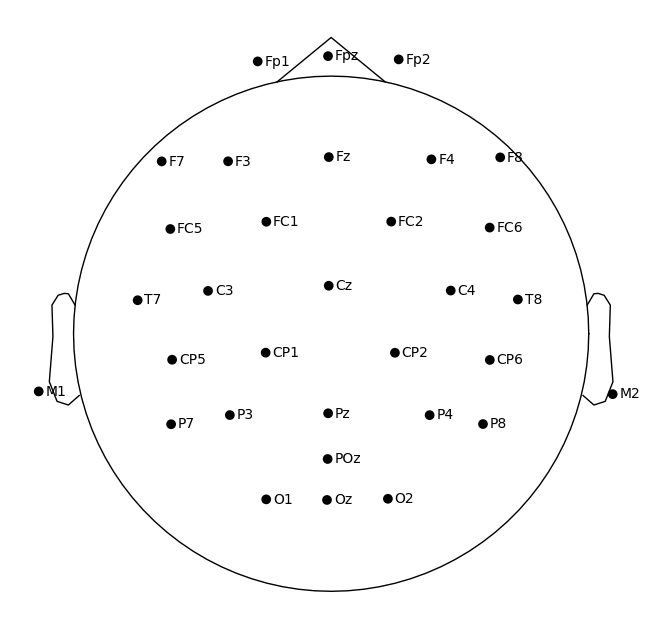

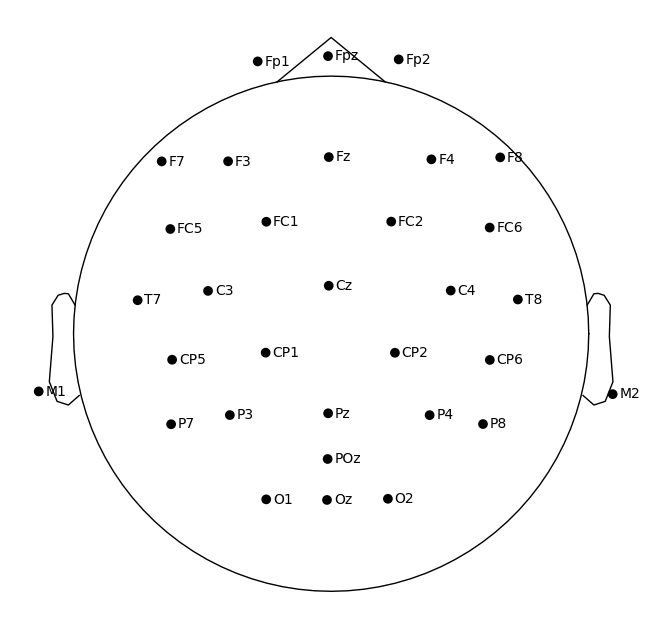

In [ ]:
raw.plot_sensors(show_names=True, title="EEG Sensor Positions")

In [ ]:
## Events and Stim triggers

In [ ]:
# raw, _ = mne.set_eeg_reference(raw)
# raw.plot(n_channels=1, duration=4)

In [ ]:
events, event_id = mne.events_from_annotations(raw)
event_id

Used Annotations descriptions: [np.str_('0, Impedance'), np.str_('16'), np.str_('2'), np.str_('32')]


{np.str_('0, Impedance'): 1,
 np.str_('16'): 2,
 np.str_('2'): 3,
 np.str_('32'): 4}

In [ ]:

events_df = pd.DataFrame(events, columns=['Onset', 'Sample', 'Trigger_Code'])

# Add time in seconds (assuming sample rate is in raw.info['sfreq'])
sfreq = raw.info['sfreq']
events_df['Time_seconds'] = events_df['Onset'] / sfreq

# Map trigger codes to meaningful names (if known)
# Example: event_id contains mapping like { 'stimulus_1': 1, 'response': 2 }
trigger_mapping = {v: k for k, v in event_id.items()}
events_df['Trigger_Name'] = events_df['Trigger_Code'].map(trigger_mapping)

print("Events extracted:")
print(events_df.head(10))
print(f"\nTotal events: {len(events_df)}")
print(f"Unique triggers: {events_df['Trigger_Name'].unique()}")

# Summary of trigger frequencies
trigger_summary = events_df['Trigger_Name'].value_counts()
print("\nTrigger frequency:")
print(trigger_summary)

Events extracted:
     Onset  Sample  Trigger_Code  Time_seconds  Trigger_Name
0        0       0             1        0.0000  0, Impedance
1    40858       0             3       20.4290             2
2  1238885       0             3      619.4425             2
3  1238999       0             2      619.4995            16
4  1309493       0             4      654.7465            32
5  1541032       0             2      770.5160            16
6  1611143       0             4      805.5715            32
7  1843032       0             2      921.5160            16
8  1913304       0             4      956.6520            32
9  2145103       0             2     1072.5515            16

Total events: 26
Unique triggers: [np.str_('0, Impedance') np.str_('2') np.str_('16') np.str_('32')]

Trigger frequency:
Trigger_Name
32              9
16              9
2               6
0, Impedance    2
Name: count, dtype: int64


In [ ]:
# Extract sampling frequency
sfreq = raw.info['sfreq']
print(f"Sampling Frequency: {sfreq} Hz")

# Extract channel information
channels_df = pd.DataFrame({
    'Channel_Name': raw.ch_names,
    'Channel_Type': raw.get_channel_types(),
    'Channel_Index': range(len(raw.ch_names))
})

print("\nChannel Information:")
print(channels_df)

# Separate channels by type
eeg_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == 'eeg']
physio_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ in ['ecg', 'emg', 'eog', 'resp']]
other_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ not in ['eeg', 'ecg', 'emg', 'eog', 'resp']]

print(f"\nEEG Channels: {len(eeg_channels)}")
print(f"Physio Channels: {len(physio_channels)}")
print(f"Other Channels: {len(other_channels)}")

Sampling Frequency: 2000.0 Hz

Channel Information:
   Channel_Name Channel_Type  Channel_Index
0           Fp1          eeg              0
1           Fpz          eeg              1
2           Fp2          eeg              2
3            F7          eeg              3
4            F3          eeg              4
5            Fz          eeg              5
6            F4          eeg              6
7            F8          eeg              7
8           FC5          eeg              8
9           FC1          eeg              9
10          FC2          eeg             10
11          FC6          eeg             11
12           M1          eeg             12
13           T7          eeg             13
14           C3          eeg             14
15           Cz          eeg             15
16           C4          eeg             16
17           T8          eeg             17
18           M2          eeg             18
19          CP5          eeg             19
20          CP1         

In [ ]:
physio_channels_list = ['Fp1', 'Fpz', 'Fp2','BIP1']

physio_data = {}
for ch in physio_channels_list:
    ch_data, times = raw[ch, :]
    physio_data[ch] = ch_data.flatten()

# Create DataFrame with time as index
physio_df = pd.DataFrame(physio_data)
physio_df.index = times

# Add time column
physio_df['Time_seconds'] = times

print("\nPhysio DataFrame shape:", physio_df.shape)
print(physio_df.head())


Physio DataFrame shape: (8455576, 5)
                 Fp1           Fpz           Fp2          BIP1  Time_seconds
0.0000 -2.496206e-18 -1.819427e-18 -3.224654e-18  3.193314e-19        0.0000
0.0005  2.163725e-07 -4.501059e-07  3.582554e-07 -1.441056e-05        0.0005
0.0010  4.463213e-07 -8.208897e-07  7.534835e-07 -2.848337e-05        0.0010
0.0015  7.024703e-07 -1.040005e-06  1.217851e-06 -4.189524e-05        0.0015
0.0020  9.919266e-07 -1.049480e-06  1.773346e-06 -5.435047e-05        0.0020


In [ ]:
events_df['Trigger_Name'].unique()

array([np.str_('0, Impedance'), np.str_('2'), np.str_('16'),
       np.str_('32')], dtype=object)

In [ ]:
# Identify EEG channels
eeg_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == 'eeg']

# ============================================================
# METHOD 1: Extract CTT triggers based on naming patterns
# ============================================================

# First, see what triggers you have available
print("="*60)
print("AVAILABLE TRIGGERS IN YOUR DATA:")
print("="*60)
unique_triggers = events_df['Trigger_Name'].unique()
for i, trigger in enumerate(unique_triggers):
    count = len(events_df[events_df['Trigger_Name'] == trigger])
    print(f"{i+1}. {trigger}: {count} occurrences")

# Identify CTT-related triggers (customize based on your experiment)
# Look for patterns like 'CTT', 'task', 'stimulus', 'trial', 'cue', 'target'
ctt_keywords = []

ctt_triggers = []
for keyword in ctt_keywords:
    matching_triggers = events_df[events_df['Trigger_Name'].str.contains(keyword, case=False, na=False)]['Trigger_Name'].unique()
    ctt_triggers.extend(matching_triggers)

# Remove duplicates
ctt_triggers = list(set(ctt_triggers))

print("\n" + "="*60)
print(f"IDENTIFIED CTT-RELATED TRIGGERS ({len(ctt_triggers)}):")
print("="*60)
for trigger in ctt_triggers:
    count = len(events_df[events_df['Trigger_Name'] == trigger])
    print(f"• {trigger}: {count} occurrences")

# If no CTT keywords found, use all triggers or manually specify
if len(ctt_triggers) == 0:
    print("\nWARNING: No CTT keywords found in trigger names.")
    print("Available triggers:", list(unique_triggers))
    print("\nPlease manually specify CTT triggers using one of these methods:")
    print("Option 1: ctt_triggers = ['trigger1', 'trigger2']  # Replace with actual names")
    print("Option 2: ctt_trigger_codes = [1, 2, 3]  # Replace with actual codes")
    
    # Manual specification example (MODIFY THESE BASED ON YOUR DATA):
    # ctt_triggers = ['stimulus', 'target', 'response']  # Replace with your trigger names
    # OR use trigger codes:
    ctt_trigger_codes = [4]  # Add your codes, e.g., [1, 2, 3, 4]
    
    if ctt_trigger_codes:
        ctt_triggers = events_df[events_df['Trigger_Code'].isin(ctt_trigger_codes)]['Trigger_Name'].unique()
        print(ctt_triggers)

AVAILABLE TRIGGERS IN YOUR DATA:
1. 0, Impedance: 2 occurrences
2. 2: 6 occurrences
3. 16: 9 occurrences
4. 32: 9 occurrences

IDENTIFIED CTT-RELATED TRIGGERS (0):

Available triggers: [np.str_('0, Impedance'), np.str_('2'), np.str_('16'), np.str_('32')]

Please manually specify CTT triggers using one of these methods:
Option 1: ctt_triggers = ['trigger1', 'trigger2']  # Replace with actual names
Option 2: ctt_trigger_codes = [1, 2, 3]  # Replace with actual codes
[np.str_('32')]


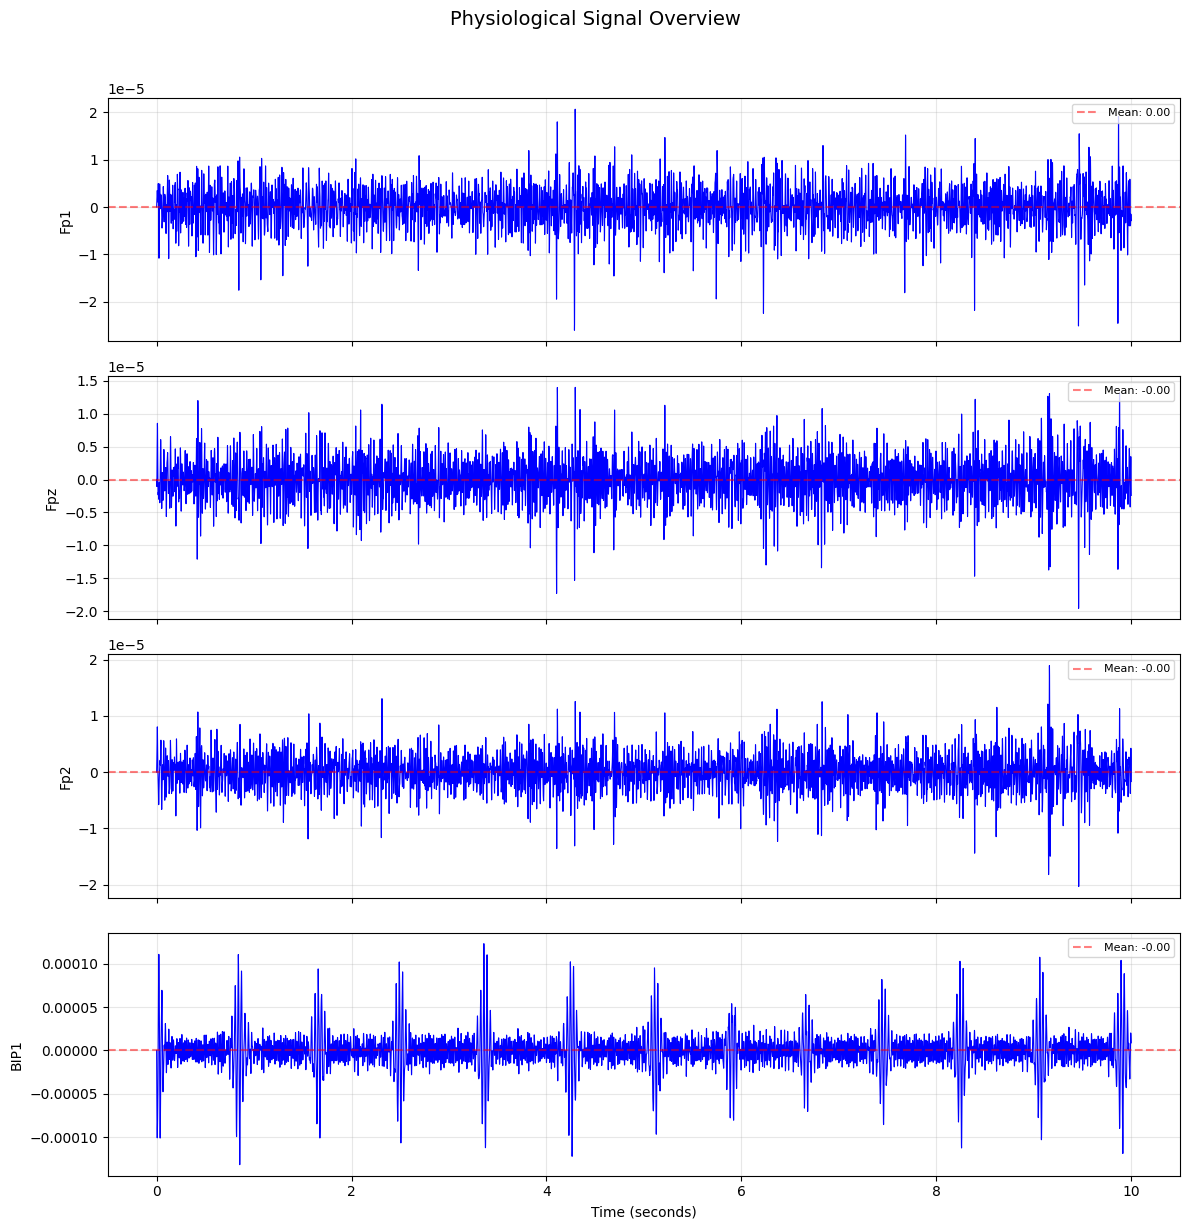

In [ ]:
def plot_physio_channels(physio_df, sfreq, duration=4):
    """Plot first 'duration' seconds of physio data"""
    time_limit = min(duration, len(physio_df) / sfreq)
    mask = physio_df['Time_seconds'] <= time_limit
    
    physio_cols = [col for col in physio_df.columns if col != 'Time_seconds']
    n_channels = len(physio_cols)
    
    if n_channels == 0:
        print("No physiological channels to plot")
        return
    
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)
    if n_channels == 1:
        axes = [axes]
    
    for i, channel in enumerate(physio_cols):
        axes[i].plot(physio_df['Time_seconds'][mask], physio_df[channel][mask], 
                     linewidth=0.8, color='b')
        axes[i].set_ylabel(channel, fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        mean_val = physio_df[channel].mean()
        std_val = physio_df[channel].std()
        axes[i].axhline(mean_val, color='r', linestyle='--', alpha=0.5, 
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend(fontsize=8, loc="upper right")
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=10)
    plt.suptitle('Physiological Signal Overview', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Execute the plots
if len(physio_channels_list) > 0:
    plot_physio_channels(physio_df, sfreq, duration=10)
else:
    print("No physiological channels found to plot")

In [ ]:
print("="*60)
print("TRIGGER ANALYSIS")
print("="*60)
# Display trigger information
print("\nTrigger Summary:")
for trigger_name in events_df['Trigger_Name'].unique():
    count = len(events_df[events_df['Trigger_Name'] == trigger_name])
    print(f"  {trigger_name}: {count} events")

CTT_START_TRIGGER = '16' 
CTT_END_TRIGGER = '32' 

def extract_ctt_trials(events_df, start_trigger, end_trigger):
    trials = []
    start_events = events_df[events_df['Trigger_Name'] == start_trigger]
    end_events = events_df[events_df['Trigger_Name'] == end_trigger]
    
    # Pair start and end events in order
    for i, (_, start_row) in enumerate(start_events.iterrows()):
        if i < len(end_events):
            end_row = end_events.iloc[i]
            trials.append({
                'trial_num': i + 1,
                'start_time': start_row['Time_seconds'],
                'end_time': end_row['Time_seconds'],
                'duration': end_row['Time_seconds'] - start_row['Time_seconds']
            })
    return trials

print(events_df)
ctt_trials = extract_ctt_trials(events_df, CTT_START_TRIGGER, CTT_END_TRIGGER)

print(f"\nFound {len(ctt_trials)} stimulation trials")
if ctt_trials:
    print(f"Trial durations range: {min(t['duration'] for t in ctt_trials):.2f} - {max(t['duration'] for t in ctt_trials):.2f} seconds")
    print(f"Average trial duration: {np.mean([t['duration'] for t in ctt_trials]):.2f} seconds")

TRIGGER ANALYSIS

Trigger Summary:
  0, Impedance: 2 events
  2: 6 events
  16: 9 events
  32: 9 events
      Onset  Sample  Trigger_Code  Time_seconds  Trigger_Name
0         0       0             1        0.0000  0, Impedance
1     40858       0             3       20.4290             2
2   1238885       0             3      619.4425             2
3   1238999       0             2      619.4995            16
4   1309493       0             4      654.7465            32
5   1541032       0             2      770.5160            16
6   1611143       0             4      805.5715            32
7   1843032       0             2      921.5160            16
8   1913304       0             4      956.6520            32
9   2145103       0             2     1072.5515            16
10  2215158       0             4     1107.5790            32
11  2436886       0             3     1218.4430             2
12  3634922       0             3     1817.4610             2
13  3639188       0         

In [ ]:
physio_df

,Fp1,Fpz,Fp2,BIP1,Time_seconds
0.0000,-2.496206e-18,-1.819427e-18,-3.224654e-18,3.193314e-19,0.0000
0.0005,2.163725e-07,-4.501059e-07,3.582554e-07,-1.441056e-05,0.0005
0.0010,4.463213e-07,-8.208897e-07,7.534835e-07,-2.848337e-05,0.0010
0.0015,7.024703e-07,-1.040005e-06,1.217851e-06,-4.189524e-05,0.0015
0.0020,9.919266e-07,-1.049480e-06,1.773346e-06,-5.435047e-05,0.0020
...,...,...,...,...,...
4227.7855,4.940991e-06,-7.149619e-06,-3.930751e-06,-5.565300e-05,4227.7855
4227.7860,3.804354e-06,-5.431085e-06,-2.834260e-06,-4.410392e-05,4227.7860
4227.7865,2.582200e-06,-3.651854e-06,-1.829440e-06,-3.058880e-05,4227.7865
4227.7870,1.304660e-06,-1.834851e-06,-8.955157e-07,-1.566197e-05,4227.7870


0.0
20.429
619.4425
619.4995
654.7465
770.516
805.5715
921.516
956.652
1072.5515
1107.579
1218.443
1817.461
1819.594
1854.889
1970.67
2005.716
2121.645
2156.696
2272.7565
2307.799
2416.535
3015.514
3019.8225
3019.9245
4227.7865


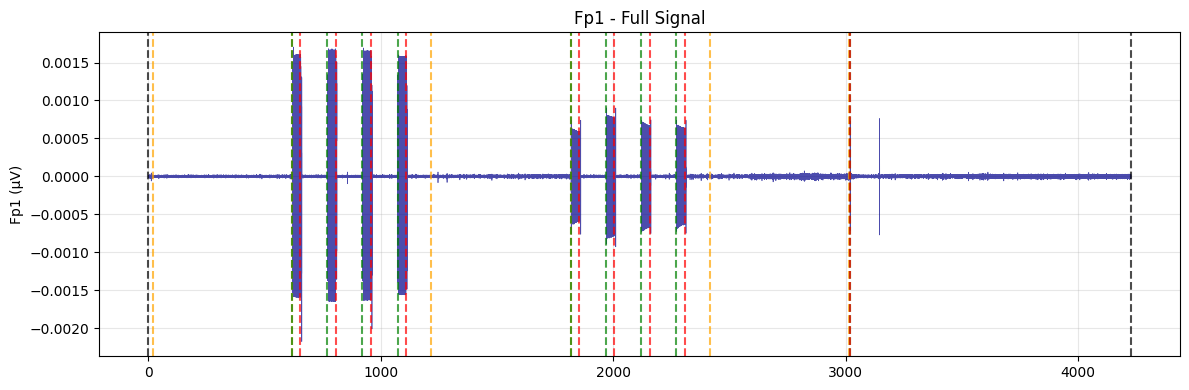

In [ ]:
def plot_individual_physio_triggers(physio_df, channel_name):
    """Plot individual physiological channel with statistics"""
    if channel_name not in physio_df.columns:
        print(f"Channel {channel_name} not found")
        return
    
    fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))
    
    # Full signal
    ax1.plot(physio_df['Time_seconds'], physio_df[channel_name], 
             linewidth=0.5, color='darkblue', alpha=0.7)
    ax1.set_ylabel(f'{channel_name} (µV)', fontsize=10)
    ax1.set_title(f'{channel_name} - Full Signal', fontsize=12)
    ax1.grid(True, alpha=0.3)

    for trial_idx in range(len(events_df)):
        trial = events_df.loc[trial_idx]

        # Mark trial boundaries
        
        match (trial["Trigger_Code"]):
            case 2:
                color="green"
            case 3:
                color="orange"
            case 4:
                color="red"
            case _:
                color="black"

        ax1.axvline(trial['Time_seconds'], color=color, linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Start')
        print(trial['Time_seconds'])
        
    
    plt.tight_layout()
    plt.show()

first_physio = physio_channels_list[0]
plot_individual_physio_triggers(physio_df, first_physio)

## Basic Analysis

In [ ]:
def extract_channel(channel):
    ecg_channels = [ch for ch in raw.ch_names if channel in ch.upper()]
    if ecg_channels:
        ecg_channel = ecg_channels[0]
        print(f"Using ECG channel: {ecg_channel}")
        
        # Extract full ECG data
        data, times = raw[ecg_channel, :]
        data = data.flatten()
        sampling_rate = raw.info['sfreq']
        
        print(f"ECG data shape: {data.shape}")
        print(f"Sampling rate: {sampling_rate} Hz")
        return data, times

data, times = extract_channel("FP1")

Using ECG channel: Fp1
ECG data shape: (8455576,)
Sampling rate: 2000.0 Hz


### Pre-stim ECG Analysis

In [ ]:
def extract_stim_ecg_epochs(ctt_trials, data, times, sampling_rate, duration=30):
    """Extract ECG epochs before each trial onset using NeuroKit2"""
    epochs = []

    print(ctt_trials)
    
    for trial in ctt_trials:
        start_time = trial['start_time']
        end_time = trial['end_time']
        
        # Find indices
        start_idx = int(start_time * sampling_rate)
        end_idx = int(end_time * sampling_rate)
        ramp_down = int(6*sampling_rate)
        
        # Extract epoch
        pre_signal = data[start_idx - int(duration*sampling_rate):start_idx]
        stim_signal = data[start_idx:end_idx + ramp_down]
        pos_signal = data[end_idx + ramp_down:end_idx + int(duration*sampling_rate) + ramp_down]

        pre_times = times[start_idx - int(duration*sampling_rate):start_idx]
        stim_times = times[start_idx:end_idx + ramp_down] # Center at 0 (trial onset)
        pos_times = times[end_idx + ramp_down:end_idx + int(duration*sampling_rate) + ramp_down]
        
        epochs.append({
            'trial_num': trial['trial_num'],
            'signal': [pre_signal, stim_signal, pos_signal],
            'times': [pre_times, stim_times, pos_times],
            'duration': duration
        })
    
    return epochs

In [ ]:
stim_epochs = extract_stim_ecg_epochs(ctt_trials[:6], data, times, sfreq)

[{'trial_num': 1, 'start_time': 619.4995, 'end_time': np.float64(654.7465), 'duration': np.float64(35.24699999999996)}, {'trial_num': 2, 'start_time': 770.516, 'end_time': np.float64(805.5715), 'duration': np.float64(35.05550000000005)}, {'trial_num': 3, 'start_time': 921.516, 'end_time': np.float64(956.652), 'duration': np.float64(35.13600000000008)}, {'trial_num': 4, 'start_time': 1072.5515, 'end_time': np.float64(1107.579), 'duration': np.float64(35.02749999999992)}, {'trial_num': 5, 'start_time': 1819.594, 'end_time': np.float64(1854.889), 'duration': np.float64(35.294999999999845)}, {'trial_num': 6, 'start_time': 1970.67, 'end_time': np.float64(2005.716), 'duration': np.float64(35.04599999999982)}]


In [ ]:
stim_epochs[0]

{'trial_num': 1,
 'signal': [array([-5.68552556e-06, -5.02983959e-06, -4.19101050e-06, ...,
          6.70554778e-06,  8.67582910e-06,  1.03667174e-05], shape=(60000,)),
  array([ 1.16849836e-05,  1.25526709e-05,  1.29148828e-05, ...,
          1.37717413e-06,  5.43017299e-07, -1.17962517e-07], shape=(82494,)),
  array([-5.52394279e-07, -7.27155284e-07, -6.34012327e-07, ...,
         -3.17877750e-06, -2.82533157e-06, -2.27634751e-06], shape=(60000,))],
 'times': [array([589.4995, 589.5   , 589.5005, ..., 619.498 , 619.4985, 619.499 ],
        shape=(60000,)),
  array([619.4995, 619.5   , 619.5005, ..., 660.745 , 660.7455, 660.746 ],
        shape=(82494,)),
  array([660.7465, 660.747 , 660.7475, ..., 690.745 , 690.7455, 690.746 ],
        shape=(60000,))],
 'duration': 30}

In [ ]:
stim_epochs[0]['times']

[array([589.4995, 589.5   , 589.5005, ..., 619.498 , 619.4985, 619.499 ],
       shape=(60000,)),
 array([619.4995, 619.5   , 619.5005, ..., 660.745 , 660.7455, 660.746 ],
       shape=(82494,)),
 array([660.7465, 660.747 , 660.7475, ..., 690.745 , 690.7455, 690.746 ],
       shape=(60000,))]

In [ ]:
def plot_epochs(epoch):
        fig = plt.figure(figsize=(12, 8), layout="constrained")
        spec = fig.add_gridspec(3, 3)


        for i in range(3):
                ax = fig.add_subplot(spec[0,i])
                ax.axhline(np.mean(epoch["signal"][i]), color="red")
                ax.plot(epoch['times'][i], epoch['signal'][i], 
                        linewidth=0.5, color='darkblue', alpha=0.7)
                ax.set_title(f'Signal {i}', fontsize=10)
                ax.set_xlabel('Time (s)')
                ax.set_ylabel('Amplitude')
                
                ax = fig.add_subplot(spec[1,i])
                fs = 1 / (epoch['times'][i][1] - epoch['times'][i][0])

                data = epoch['signal'][i]
                f, t, Sxx = scipy.signal.spectrogram(data, fs, 
                                        nperseg=min(256, len(data)//2),
                                        noverlap=128,
                                        scaling='density')
                
                # Plot spectrogram (row 1)
                im = ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), 
                                        shading='gouraud', cmap='jet')
                ax.set_title(f'Spectrogram {i}', fontsize=10)
                ax.set_xlabel('Time (s)')
                ax.set_ylabel('Frequency (Hz)')
                ax.set_ylim([0, min(fs/2, 50)])  # Limit to relevant frequencies (adjust as needed)
                
                # Add colorbar for the last subplot
                # if i == len(epoch["signal"]) - 1:
                #         plt.colorbar(im, ax=ax[1, i], label='Power/Frequency (dB/Hz)')
        
        full_signal = np.concatenate(epoch["signal"])
        full_times = np.concatenate(epoch['times'])
        
        # Calculate overall mean
        overall_mean = np.mean(full_signal)


        ax = fig.add_subplot(spec[2, :])
        ax.plot(full_times, full_signal, linewidth=0.5, color='darkgreen', alpha=0.7)
        ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1, alpha=0.8)

        plt.tight_layout()
        plt.show()

C:\Users\Jose\AppData\Local\Temp\ipykernel_17668\1471921984.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


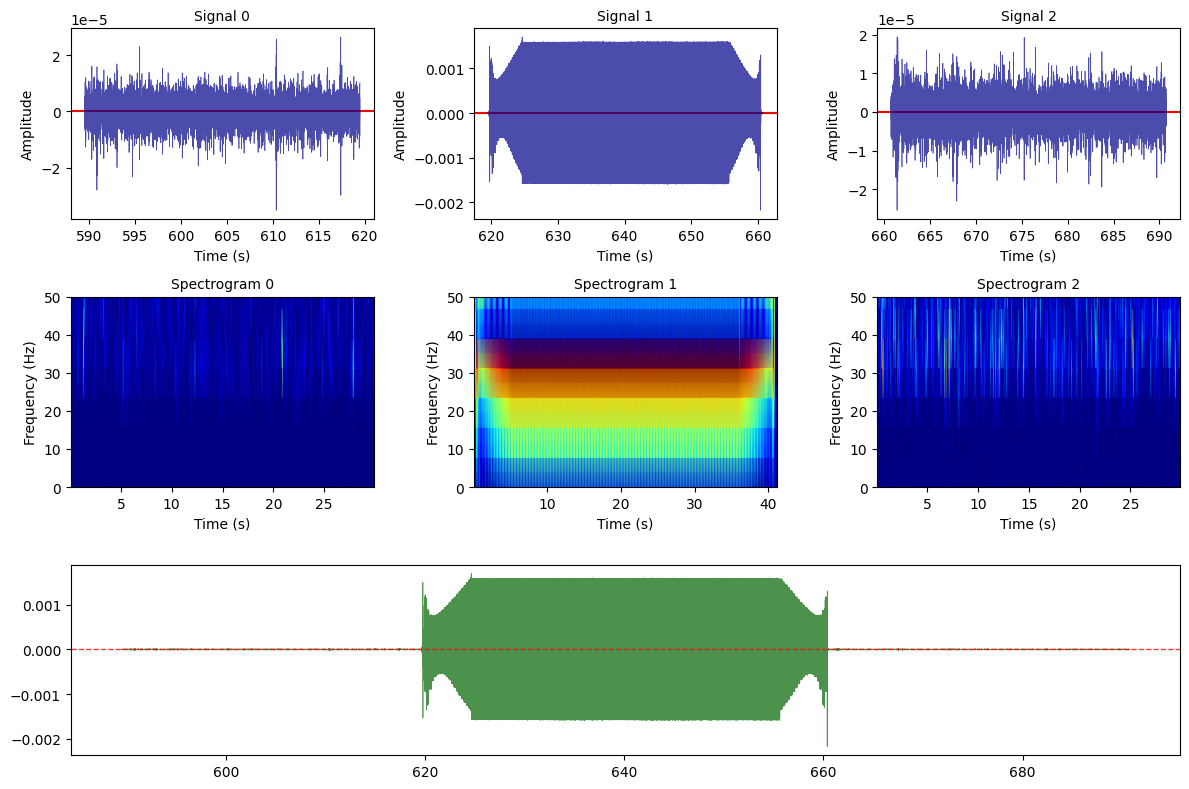

In [ ]:
plot_epochs(stim_epochs[0])

C:\Users\Jose\AppData\Local\Temp\ipykernel_17668\1471921984.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


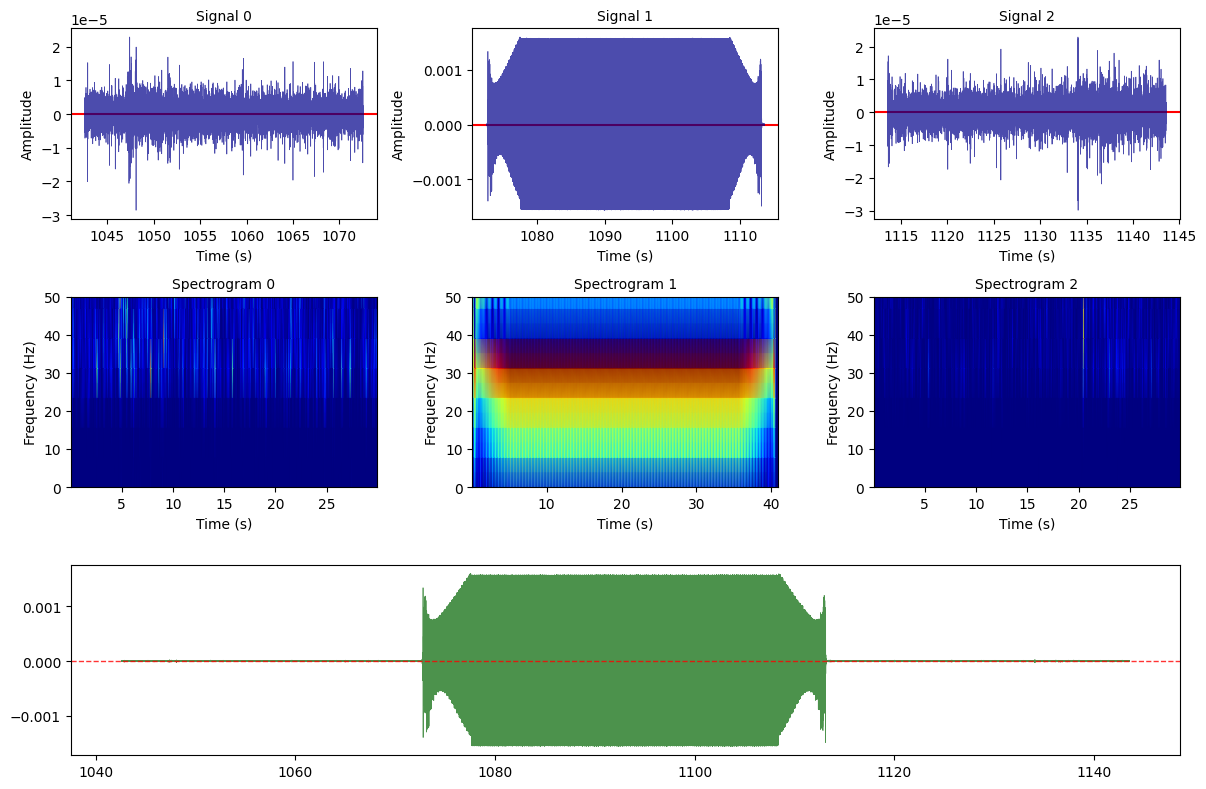

In [ ]:
plot_epochs(stim_epochs[3])

C:\Users\Jose\AppData\Local\Temp\ipykernel_17668\1471921984.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


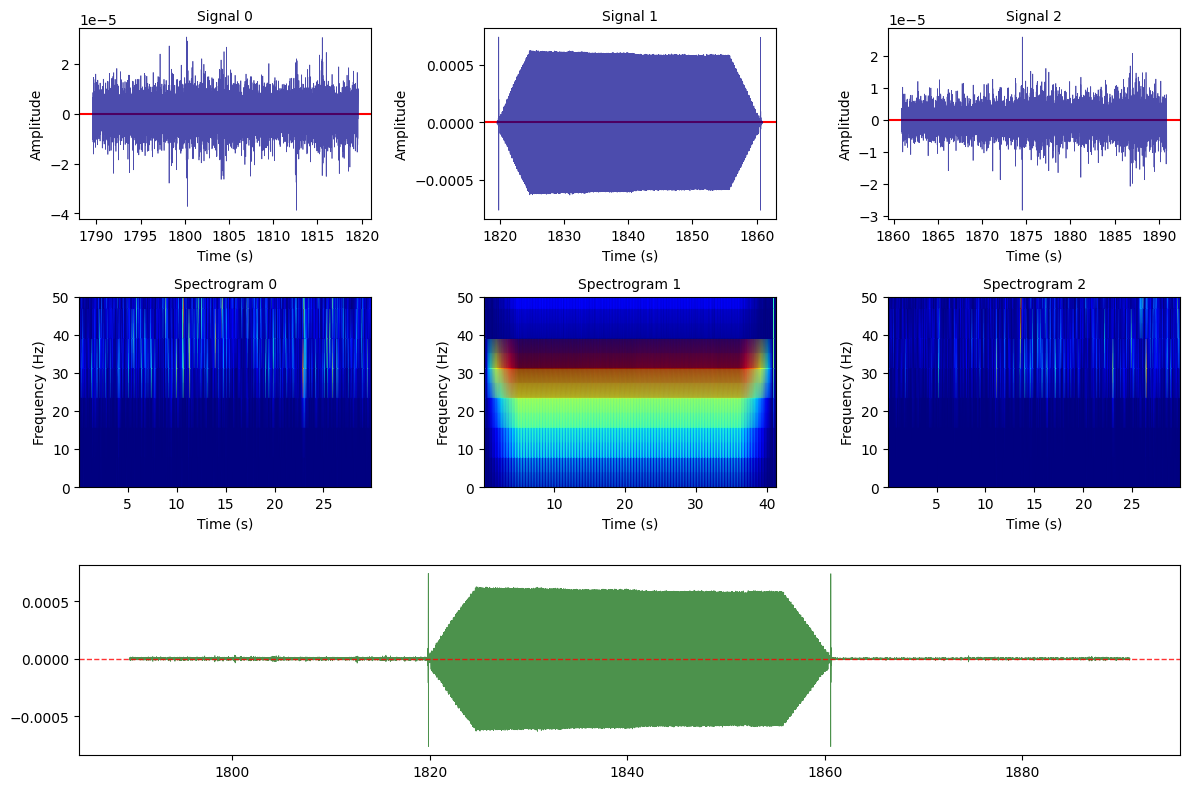

In [ ]:
plot_epochs(stim_epochs[4])

In [ ]:
plot_epochs(stim_epochs[7])

IndexError: list index out of range

In [ ]:
def process_ecg_epochs(epochs, sampling_rate, stim_moment=0):
    """Process each ECG epoch using NeuroKit2"""
    processed_epochs = []
    
    for epoch in epochs:
        # Use NeuroKit2's complete ECG processing pipeline [citation:2][citation:9]
        signals, info = nk.ecg_process(
            epoch['signal'][stim_moment], 
            sampling_rate=sampling_rate
        )
        nk.ecg_plot(signals, info)
        
        fig = plt.gcf()
        fig.set_size_inches(20, 6)
        plt.subplots_adjust(hspace=0.4)
        plt.show()
        
        processed_epochs.append({
            'trial_num': epoch['trial_num'],
            'signals': signals,
            'info': info,
            'times': epoch['times']
        })
    
    return processed_epochs

# Process all pre-stimulus epochs
processed_epochs = process_ecg_epochs(stim_epochs[:1], sampling_rate)
print(f"Processed {len(processed_epochs)} epochs")

NameError: name 'sampling_rate' is not defined

In [ ]:
def extract_heartbeat_features(processed_epochs):
    """Extract R-peaks and heart rate features"""
    all_rpeaks = []
    all_heart_rates = []
    
    for epoch in processed_epochs:
        # R-peak locations (in samples) from NeuroKit2 [citation:3][citation:10]
        rpeaks = epoch['info']['ECG_R_Peaks']
        
        # Convert to time (relative to epoch start)
        rpeak_times = rpeaks / sampling_rate
        
        # Calculate instantaneous heart rate
        if len(rpeaks) > 1:
            # RR intervals in milliseconds
            rr_intervals = np.diff(rpeaks) / sampling_rate * 1000
            heart_rate = 60000 / rr_intervals  # bpm
        else:
            heart_rate = []
            rr_intervals = []
        
        all_rpeaks.append({
            'trial_num': epoch['trial_num'],
            'rpeak_indices': rpeaks,
            'rpeak_times': rpeak_times,
            'rr_intervals': rr_intervals,
            'heart_rate': heart_rate
        })
        
        # Calculate mean heart rate for this epoch
        if len(rr_intervals) > 0:
            mean_hr = np.mean(60000 / rr_intervals)
        else:
            mean_hr = np.nan
        all_heart_rates.append(mean_hr)
    
    return all_rpeaks, all_heart_rates

rpeaks_data, heart_rates = extract_heartbeat_features(processed_epochs)

c:\Dev\GX_tES_Dataset_Experiment\.venv\Lib\site-packages\neurokit2\complexity\entropy_multiscale.py:346: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapezoid(mse) / len(mse)
c:\Dev\GX_tES_Dataset_Experiment\.venv\Lib\site-packages\neurokit2\complexity\optim_complexity_k.py:134: RuntimeWarning: divide by zero encountered in divide
  normalization = (n - 1) / (np.floor((n - k_subrange) / k).astype(int) * k)
c:\Dev\GX_tES_Dataset_Experiment\.venv\Lib\site-packages\neurokit2\complexity\optim_complexity_k.py:135: RuntimeWarning: invalid value encountered in multiply
  sets = (np.nansum(np.abs(np.diff(sig_values)), axis=1) * normalization) / k


ValueError: `bins` must be positive, when an integer

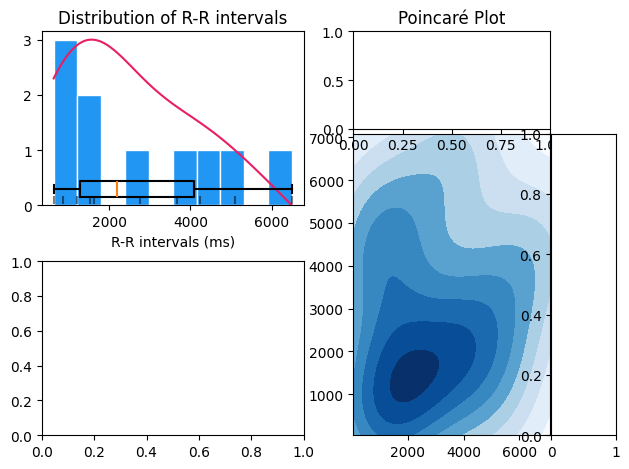

In [ ]:
def calculate_hrv_metrics(rpeaks_data, sampling_rate):
    """Calculate HRV metrics using NeuroKit2"""
    hrv_metrics = []
    
    for epoch in rpeaks_data:
        if len(epoch['rr_intervals']) >= 2:  # Need at least 2 beats for HRV

            hrv_indices_pre = nk.hrv(epoch['rpeak_indices'], sampling_rate=sampling_rate, show=True)

            fig = plt.gcf()
            fig.set_size_inches(10, 6)
            plt.subplots_adjust(hspace=0.4, wspace=0.3) 
            plt.show()
            
            # Combine all metrics
            trial_metrics = pd.concat([hrv_indices_pre], axis=1)
            trial_metrics.index = [f'Trial_{epoch["trial_num"]}']
            hrv_metrics.append(trial_metrics)
        else:
            print(f"Trial {epoch['trial_num']}: Insufficient beats for HRV ({len(epoch['rr_intervals'])} intervals)")
    
    if hrv_metrics:
        return pd.concat(hrv_metrics)
    else:
        return pd.DataFrame()

# Calculate HRV metrics
hrv_results = calculate_hrv_metrics(rpeaks_data, sampling_rate)
print("\nHRV Metrics Summary:")
hrv_results

In [ ]:
processed_post_epochs = process_ecg_epochs(post_stim_epochs[:1], sampling_rate)
print(f"Processed {len(processed_post_epochs)} epochs")

NameError: name 'post_stim_epochs' is not defined